Salient Object Detection — Live Demo

Upload an image → see the predicted saliency mask in seconds.


## Setup

This cell mounts Drive, loads the trained model, and defines the helper functions.
After it finishes, you only need to run the **Demo** cell during your recording.


In [ ]:
# ---- Mount Drive ----
from google.colab import drive
drive.mount('/content/drive')

# ---- Imports ----
import os, time, io
import numpy as np
import torch
import torch.nn as nn
import torchvision.transforms.functional as TF
import matplotlib.pyplot as plt
from PIL import Image
from google.colab import files

# ---- Config ----
PROJECT_DIR     = "/content/drive/MyDrive/sod_project"
CHECKPOINT_PATH = os.path.join(PROJECT_DIR, "checkpoints/best_model.pt")
IMAGE_SIZE      = 224          # match what you trained with
DROPOUT_P       = 0.3
DEVICE          = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ---- Model definition (same architecture as training) ----
class ConvBlock(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.block(x)


class UpBlock(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.block = nn.Sequential(
            nn.ConvTranspose2d(in_c, out_c, 2, stride=2),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.block(x)


class SODModel(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, dropout_p=0.3):
        super().__init__()
        self.enc1 = ConvBlock(in_channels, 32)
        self.enc2 = ConvBlock(32, 64)
        self.enc3 = ConvBlock(64, 128)
        self.enc4 = ConvBlock(128, 256)
        self.pool = nn.MaxPool2d(2, 2)
        self.bottleneck = nn.Sequential(
            nn.Conv2d(256, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Dropout2d(p=dropout_p),
        )
        self.up1 = UpBlock(256, 128)
        self.up2 = UpBlock(128, 64)
        self.up3 = UpBlock(64, 32)
        self.up4 = UpBlock(32, 16)
        self.out_conv = nn.Conv2d(16, out_channels, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.pool(self.enc1(x))
        x = self.pool(self.enc2(x))
        x = self.pool(self.enc3(x))
        x = self.pool(self.enc4(x))
        x = self.bottleneck(x)
        x = self.up1(x); x = self.up2(x); x = self.up3(x); x = self.up4(x)
        return self.sigmoid(self.out_conv(x))


# ---- Load the trained model ----
model = SODModel(dropout_p=DROPOUT_P).to(DEVICE)
ckpt = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
state_dict = ckpt["model_state_dict"] if "model_state_dict" in ckpt else ckpt
model.load_state_dict(state_dict)
model.eval()


# ---- Inference helper ----
def predict(image_path_or_pil, size=IMAGE_SIZE):
    """Run the model on an image and return (input, mask, overlay, ms)."""
    pil = (Image.open(image_path_or_pil) if isinstance(image_path_or_pil, str)
           else image_path_or_pil).convert("RGB").resize((size, size), Image.BILINEAR)
    tensor = TF.to_tensor(pil).unsqueeze(0).to(DEVICE)

    start = time.time()
    with torch.no_grad():
        pred = model(tensor)
    ms = (time.time() - start) * 1000.0

    img_np  = np.array(pil).astype(np.float32) / 255.0
    pred_np = pred.squeeze().cpu().numpy()
    binary  = (pred_np > 0.5).astype(np.float32)

    # Red overlay where the model predicts "salient"
    overlay = img_np.copy()
    overlay[..., 0] = np.where(binary > 0.5, 1.0, overlay[..., 0])
    overlay[..., 1] = np.where(binary > 0.5, overlay[..., 1] * 0.4, overlay[..., 1])
    overlay[..., 2] = np.where(binary > 0.5, overlay[..., 2] * 0.4, overlay[..., 2])
    return img_np, pred_np, overlay, ms


def show_results(img_np, pred_np, overlay, ms):
    """Big, clean side-by-side plot — looks good on screen recording."""
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(img_np);              axes[0].set_title("Input image",      fontsize=14)
    axes[1].imshow(pred_np, cmap="gray"); axes[1].set_title("Predicted mask",   fontsize=14)
    axes[2].imshow(overlay);             axes[2].set_title("Overlay",          fontsize=14)
    for ax in axes: ax.axis("off")
    plt.suptitle(f"Inference time: {ms:.1f} ms", fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()


print("\n✅ Model loaded.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

✅ Model loaded.


---

## 🎬 Demo — run this cell during the recording

Click the cell, run it, pick an image from your computer → result appears in ~1 second.


Saving ILSVRC2012_test_00000004.jpg to ILSVRC2012_test_00000004 (1).jpg


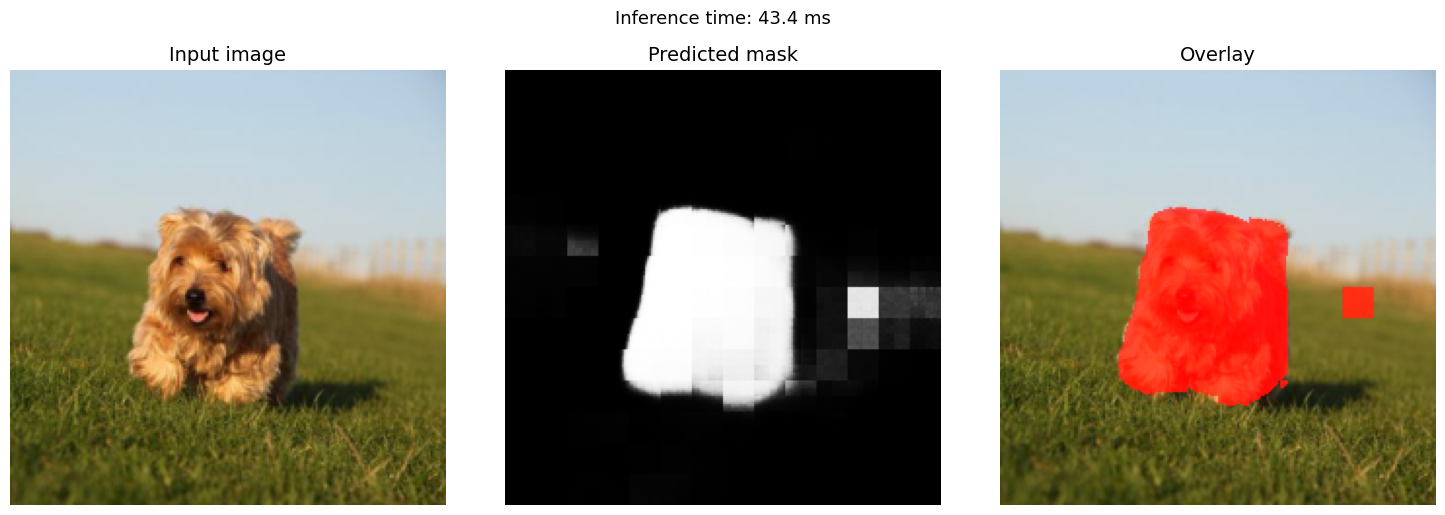

In [ ]:
uploaded = files.upload()                   # pops up a file picker
for filename in uploaded.keys():
    img, mask, overlay, ms = predict(filename)
    show_results(img, mask, overlay, ms)


---

### Backup option — predict on a sample from your dataset

If the file upload acts up during recording, run this instead. Picks a random
image from your dataset folder.


In [ ]:
import random

IMAGES_DIR = os.path.join(PROJECT_DIR, "dataset/images")
files_list = sorted([f for f in os.listdir(IMAGES_DIR)
                     if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
sample = random.choice(files_list)
print(f"Sample: {sample}")

img, mask, overlay, ms = predict(os.path.join(IMAGES_DIR, sample))
show_results(img, mask, overlay, ms)
